In [32]:
# Import Libraries
# --------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [33]:


# Load the Dataset
# --------------------------------
# The CSV file contains a trailing comma in the header, creating an extra unnamed column.
df = pd.read_csv('/content/data.csv')
# Drop any column whose name starts with 'Unnamed' (this removes the extra column)
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [34]:

# Basic Preprocessing
# --------------------------------
# Check for missing values
# The dataset is known to be clean, but we verify.
print(df.isnull().sum())   # No missing values expected


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [35]:
# Encode target variable
# 'diagnosis' column: M (malignant) → 1, B (benign) → 0
# LabelEncoder converts categorical labels to numeric.
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])
print("Class distribution:\n", df['diagnosis'].value_counts())
# Output shows roughly 357 benign (0) and 212 malignant (1) – a slight imbalance.

Class distribution:
 diagnosis
0    357
1    212
Name: count, dtype: int64


In [36]:
# Separate features and target
# 'id' column is not useful for modeling; drop it along with target.
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']
print("Features shape:", X.shape)   # (569, 30) – 30 numeric features
print("Target shape:", y.shape)

Features shape: (569, 30)
Target shape: (569,)


In [37]:
# Train-test split
# We use stratify=y to preserve the class distribution in both train and test sets.
# Test size = 20% of data.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Training samples: 455
Test samples: 114


In [38]:
# Feature scaling
# IMPORTANT: SVM and KNN are distance-based algorithms. Features on different scales
# would dominate the distance calculation. We use StandardScaler to standardize
# (mean=0, std=1) based on training data, then transform test data.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [39]:
# Model Training and Evaluation
# --------------------------------
# 4Support Vector Machine (SVM)
# SVM tries to find the hyperplane that maximizes the margin between classes.
# We test four kernels because each has a different decision boundary shape:
# - linear: best if data is linearly separable
# - rbf (Radial Basis Function): good for non-linear data; maps to infinite dimensions
# - sigmoid: similar to a neural network; not always stable
# - polynomial: creates polynomial decision boundaries

kernels = ['linear', 'rbf', 'sigmoid', 'poly']
svm_results = {}

for kernel in kernels:
    svm = SVC(kernel=kernel, random_state=42)
    svm.fit(X_train_scaled, y_train)
    y_pred = svm.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    svm_results[kernel] = {'accuracy': acc, 'confusion_matrix': cm}

    print(f"\nSVM ({kernel})")
    print(f"Accuracy: {acc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    # classification_report gives precision, recall, f1-score per class
    print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))



SVM (linear)
Accuracy: 0.9649
Confusion Matrix:
[[72  0]
 [ 4 38]]
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97        72
   Malignant       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


SVM (rbf)
Accuracy: 0.9737
Confusion Matrix:
[[72  0]
 [ 3 39]]
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114


SVM (sigmoid)
Accuracy: 0.9474
Confusion Matrix:
[[71  1]
 [ 5 37]]
              precision    recall  f1-score   support

      Benign       0.93      0.99      0.96        72
   Malignant       0.97      0.88  

In [40]:
# K-Nearest Neighbors (KNN)
# KNN classifies a point by majority vote of its k nearest neighbors.
# k=5 is a common starting point; scaling is critical here because distances
# between points are used to find neighbors.
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)

print("\nKNN (k=5)")
print(f"Accuracy: {acc_knn:.4f}")
print("Confusion Matrix:")
print(cm_knn)
print(classification_report(y_test, y_pred_knn, target_names=['Benign', 'Malignant']))


KNN (k=5)
Accuracy: 0.9561
Confusion Matrix:
[[71  1]
 [ 4 38]]
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



In [41]:
# Model Comparison
# --------------------------------
# Accuracy Summary
print("\n--- Model Comparison ---")
for kernel, res in svm_results.items():
    print(f"SVM ({kernel}): {res['accuracy']:.4f}")
print(f"KNN (k=5)      : {acc_knn:.4f}")



--- Model Comparison ---
SVM (linear): 0.9649
SVM (rbf): 0.9737
SVM (sigmoid): 0.9474
SVM (poly): 0.8860
KNN (k=5)      : 0.9561


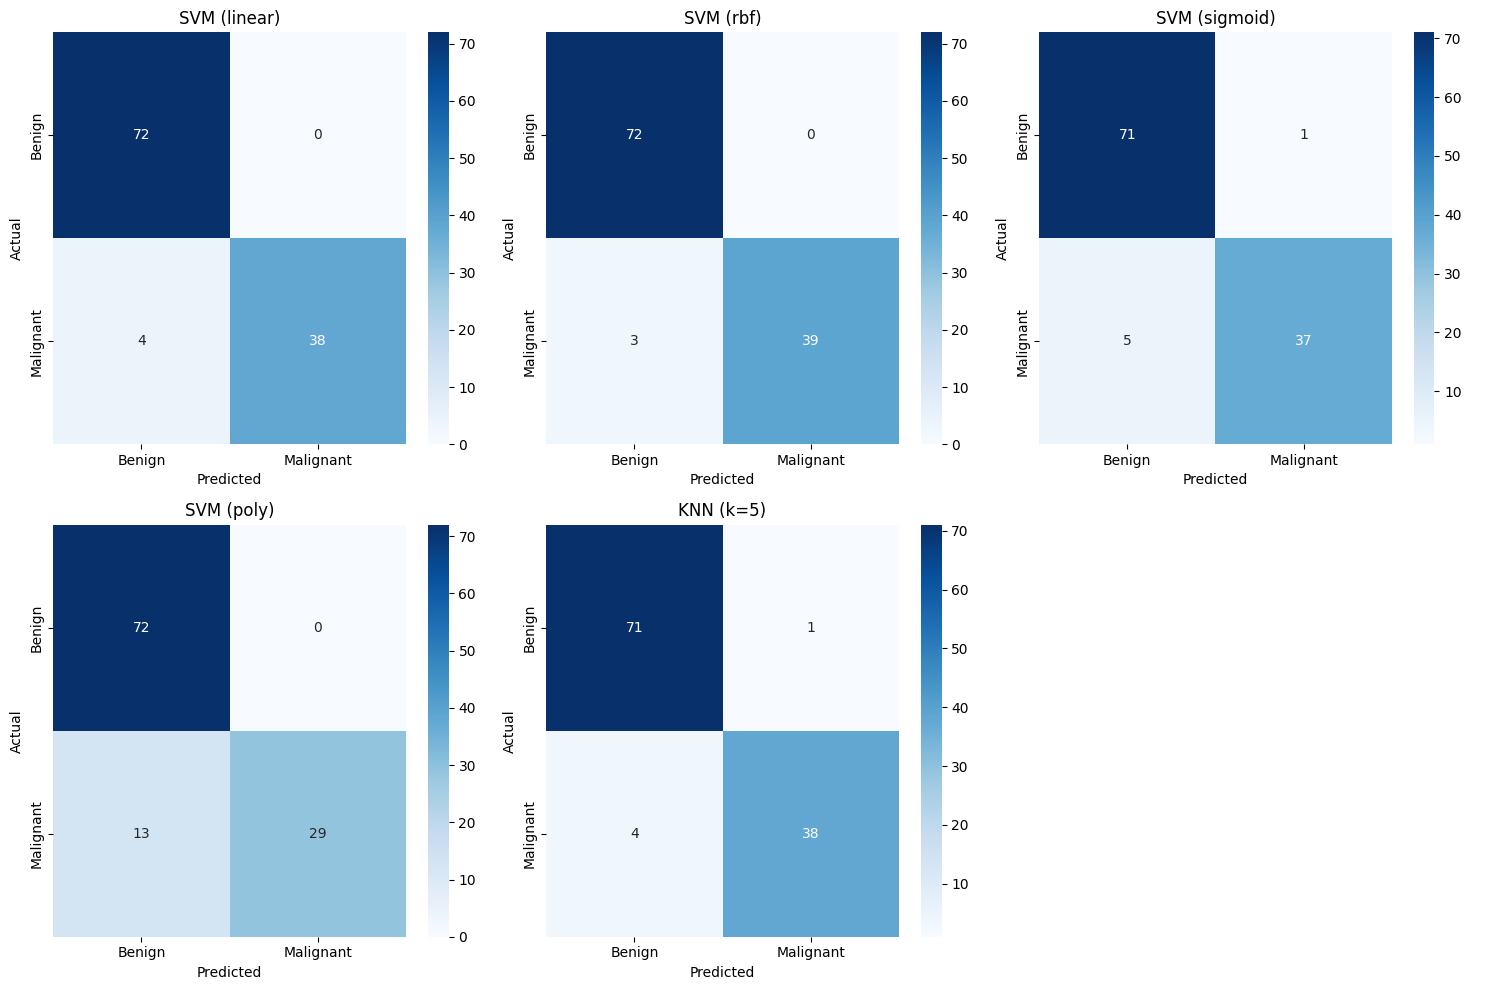

In [42]:

# Visualizing Confusion Matrices
# Confusion matrices help us see where the model makes mistakes.
# - True Negatives (top-left): correctly predicted benign
# - False Positives (top-right): benign predicted as malignant
# - False Negatives (bottom-left): malignant predicted as benign
# - True Positives (bottom-right): correctly predicted malignant
# For medical diagnosis, minimizing false negatives (missing cancer) is critical.

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

# Plot SVM kernels
for i, kernel in enumerate(kernels):
    cm = svm_results[kernel]['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
    axes[i].set_title(f'SVM ({kernel})')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Plot KNN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[4],
            xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
axes[4].set_title('KNN (k=5)')
axes[4].set_xlabel('Predicted')
axes[4].set_ylabel('Actual')

# Hide unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()